<a href="https://colab.research.google.com/github/dkhan1209/Face-Recognition/blob/main/FaceRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = '/content/drive/MyDrive/Ảnh Lớp IC'
img_width, img_height=280, 280
batch_size= 32
train_datagen = ImageDataGenerator(
    rescale= 1.0/255,
    rotation_range= 30,
    width_shift_range= 0.2,
    height_shift_range= 0.2,
    shear_range= 0.2,
    zoom_range= 0.2,
    horizontal_flip= True,
    fill_mode= 'nearest'
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size= (img_width, img_height),
    batch_size= batch_size,
    class_mode= 'categorical'
)

Found 1606 images belonging to 34 classes.


In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(34, activation='softmax') # Changed from 8 to 34 to match the number of classes
])

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs=5)

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.4390 - loss: 1.8711
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5081 - loss: 1.6248
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5866 - loss: 1.3053
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.6059 - loss: 1.2385
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6351 - loss: 1.1731


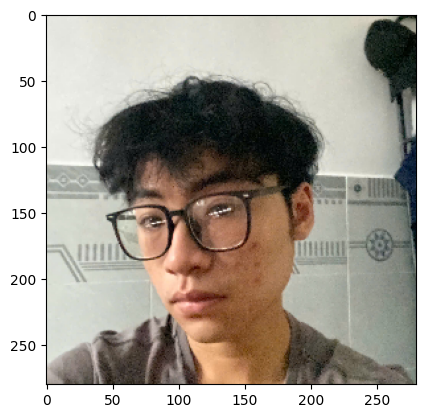

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Người tiên đoán:Hữu Tài


In [19]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt #

path= '/content/z7869475650656_c77e90300714499b2ec8b017e6fd284f.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img = np.array(img)
img=img/255.0
img= img.reshape(1,img_width,img_height,3) # Corrected reshape dimensions
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
person_name=class_labels[prediction]
print(f'Người tiên đoán:{person_name}')

In [18]:
model.save('ht.h5')
from keras.models import load_model
model = load_model('ht.h5')
